In [47]:
import os
import math
import numpy as np
import scipy.special as spf
import scipy.interpolate as interp
import time
import quaternionic as qnc 
import h5py
import sys
import matplotlib.pyplot as plt
import matplotlib.colors as clr
plt.rc('text', usetex=True)


import vsdm
from vsdm.units import *
from vsdm.utilities import *
from vsdm import McalK


diffM, diffV = vsdm.testG_lm(5, -3, printout=False)
if np.abs(diffV) < 1e-14:
    print("testing 'spherical' and WignerG: PASS")
else:
    print("testing 'spherical' and WignerG: FAIL")
    print("check the version number for 'spherical', and run testD_lm()")
print("vsdm", vsdm.__version__)

deg = np.pi/180
unisize = 3.5

from scipy import optimize
from scipy.integrate import quad, nquad

from scipy.special import erf
from scipy.optimize import brentq, minimize_scalar
from scipy.stats import poisson, chi2

#constants
c = 299792 #(km/s)

print("I'm working")

ERROR! Session/line number was not unique in database. History logging moved to new session 342
testing 'spherical' and WignerG: PASS
vsdm 0.4.4
I'm working


In [20]:
### Quaternion rotation from Ben's code:aka all the rotation function things

def getQ(theta, phi):
    #theta, phi should be in radians
    axisphi = phi + np.pi/2 #stationary under R
    axR = theta/2 
    qr = np.cos(axR)
    qi = np.sin(axR) * np.cos(axisphi)
    qj = np.sin(axR) * np.sin(axisphi)
    qk = 0. 
    return qnc.array(qr, qi, qj, qk)

def rotateBy(qR, v):
    # rotate a vector v (or array of vectors) by rotation operator qR
    return qR * v / qR

def conicalABN(v, a, b, th):
    eq1 = v@v - 1 #I think this is doing matrix multiplication 
    eq2 = (v@a - np.cos(th))**2
    eq3 = (v@b - np.cos(th))**2 
    return eq1 + eq2 + eq3

def nhat(theta, phi):
    nx = np.sin(theta) * np.cos(phi) 
    ny = np.sin(theta) * np.sin(phi) 
    nz = np.cos(theta) 
    return np.array([nx, ny, nz])


def rotationQ(theta, phi, alpha):
    "Encodes a rotation by angle 'alpha' about the (theta,phi) unit vector."
    nx,ny,nz = nhat(theta, phi)
    axR = alpha/2 
    cosah = np.cos(alpha/2) 
    sinah = np.sin(alpha/2) 
    return qnc.array(cosah, sinah*nx, sinah*ny, sinah*nz)

def qfunc(qr, vec3d):
    return qnc.array(qr, vec3d[0], vec3d[1], vec3d[2])
def findCone(thph1, thph2, thetaN):
    assert 0 < thetaN < np.pi/2, "thetaN is defined as interior cone angle, from axis of symmetry"
    theta1, phi1 = thph1 
    theta2, phi2 = thph2 
    ax1 = np.sin(theta1)*np.cos(phi1)
    ay1 = np.sin(theta1)*np.sin(phi1)
    az1 = np.cos(theta1) 
    a1 = np.array([ax1, ay1, az1])
    ax2 = np.sin(theta2)*np.cos(phi2)
    ay2 = np.sin(theta2)*np.sin(phi2)
    az2 = np.cos(theta2) 
    a2 = np.array([ax2, ay2, az2])
    assert a1 @ a2 >= np.cos(2*thetaN), "these two (theta,phi) cannot be fit to the cone."
    
    return a1 @ a2

# Specify the position of the north pole in (theta, phi)

# Draw the conical path of the DM wind in the theta, phi plane given the cone opening angle, 2*thetaN
def makeCone(theta_north, phi_north, phase, thetaN=(42*deg), dt_h=0.2):
    """Returns the Earth velocity unit vector vE as a function of time.
    
    theta_north, phi_north: a 2d unit vector specifying the location of the north pole 
        (in the crystal coordinate frame, where theta=0 is the "b=z" direction)
    phase: shifts the "t=0" starting position of vE
    thetaN: the angle between the DM wind and the north pole (radians)
    dt_h: the time step to use, in sidereal hours (24h = 360 deg)

    returns lists of tH,theta_E,phi_E, with angles in radians and times in sidereal hours
    """
    # north pole vector:
    northvec = nhat(theta_north, phi_north)
    # Step 1: find a starting position for vE, rotating "northvec" by thetaN about any orthogonal vector.
    eps = 0.005
    # default: define the rotation axis as orthogonal to "x":
    axis_init = np.cross(northvec, np.array([1, 0, 0]))
    # if northvec is colinear with "x", use the "y" axis instead:
    if np.linalg.norm(axis_init) < eps:
        axis_init = np.cross(northvec, np.array([0, 1, 0]))
    # rotate about axis_init by angle thetaN:
    one,theta_ai,phi_ai = cart_to_sph(axis_init)
    Q_init = rotationQ(theta_ai, phi_ai, thetaN)
    qnorth = qfunc(0., northvec)
    vE_init = rotateBy(Q_init, qnorth)

    Q_phase = rotationQ(theta_north, phi_north, phase)
    vE_0 = rotateBy(Q_phase, vE_init)

    # Step 2: rotate vE_0 about the north pole
    lenT = int(24.0 / dt_h) + 1 # include 24.0h at the end
    sid_times = [j*dt_h for j in range(lenT)]
    thetaE = []
    phiE = []
    for t in sid_times: 
        alpha = t/24 * 2*np.pi # rotation angle 
        Q_t = rotationQ(theta_north, phi_north, alpha) # rotation operator 
        qE_t = rotateBy(Q_t, vE_0) # rotated vector (as quaterion) 
        vE_t = qE_t.imag # convert back to 3d vector 
        one,theta,phi = cart_to_sph(vE_t) # convert to spherical coordinate
        thetaE += [theta]
        phiE += [phi]
    return np.array(sid_times), np.array(thetaE), np.array(phiE)


def dailyMod(north, thetaN, plotpoints=100, t0_h=0.):
    theta_phi_list = makeCone(north, thetaN, plotpoints=plotpoints)
    R_list = []
    t_list = []
    dt_h = 24.0/plotpoints # time between plot points, in sidereal hours
    t = t0_h #initial time, in sidereal hours
    for theta,phi in theta_phi_list:        
        q = 1/getQ(theta, phi) 
        R_list += [q]
        t_list += [t]
        t += dt_h
    return np.array(t_list),R_list

def ix_thetaphi(theta, phi):
    return thetaphilist.index((theta, phi))


In [21]:
"""import partial rate matrix from HDF5"""

ellMax = 24
mXlist = [2, 3, 5, 10, 20, 30, 50, 100]

DeltaE = {}
DeltaE['s1'] = 4.24*eV
DeltaE['s2'] = 4.788*eV
DeltaE['s5'] = 5.791*eV
DeltaE['s8'] = 6.439*eV

ellMax = 24
nvMax = 511
nqMax = 1023
lmod = 2

QMAX = 24*keV # Global value for q0=qMax for wavelets
Qbasis = dict(u0=QMAX, type='wavelet', uMax=QMAX)

VMAX = 820.*km_s # Global value for v0=vMax for wavelets
Vbasis = dict(u0=VMAX, type='wavelet', uMax=VMAX)



def h5modelname(sI, dmModel, mX_MeV_float=0):
    """Define a consistent style for labeling McalI[dmModel] in this hdf5.

    returns: ('sI') + '/' + ('fdm') + '/' + ('mX_MeV')
        fdm = dmModel['fdm']
        mX_MeV = dmModel['mX']/MeV
    mX_MeV_float controls how many decimal points to include in the
        string version of mX/MeV
    """
    fdm = dmModel['fdm']
    mX_MeV = dmModel['mX'] / MeV
    if mX_MeV_float==0:
        mX_str = str(int(mX_MeV))
    elif mX_MeV_float==1:
        mX_str = '{:.1f}'.format(mX_MeV)
    elif mX_MeV_float==2:
        mX_str = '{:.12}'.format(mX_MeV)
    elif mX_MeV_float==3:
        mX_str = '{:.3f}'.format(mX_MeV)
    mIstr = '{}/{}/{}'.format(sI, fdm, mX_str)
    return mIstr
    

### This function only needs to be run once for each (n,mX) model.
"""
"""Calculate WignerG matrix"""
rotationlist = []
rotationarray = []
thetaphilist = []

for theta in range(0, 181, 2):
    rrow = []
    for phi in range(0, 361, 2):
        # for WignerG, want to apply the inverse of getQ.
        # getQ applied to vE moves vE from the z axis to the position (theta, phi). 
        # 1/getQ applied to the crystal does the same thing, 
        #     with vE -> (theta, phi) in the frame of the crystal.
        q = 1/getQ(theta * np.pi/180, phi * np.pi/180) 
        rrow += [q] 
        rotationlist += [q] 
        thetaphilist += [(theta, phi)]
    rotationarray += [rrow]

rotationarray = np.array(rotationarray)

"""Calculate the Wigner G matrix for each rotation (takes ~2 minutes)"""
wG = vsdm.WignerG(ellMax, rotations=rotationlist, lmod=2)


thetas = [theta for theta in range(0, 181, 2)]
phis = [phi for phi in range(0, 361, 2)]
thetaphi_size = (np.shape(rotationarray)[0], np.shape(rotationarray)[1])

data_dir = os.getcwd() + '/data/'
np.save('thetas.npy', thetas)
np.save('phis.npy', phis)
# Assuming the same grid of theta,phi for all DM models. 
# If not, for some reason, add an identifying modelstring to file names above. 

def writeRinterpolated(n, mX, modelstring, sI='tot'):
    """Calculates WignerG and McalK, saves R(theta, phi) to file.
    
       n = 0,2: heavy/light mediator
       mX: (integer) DM mass in MeV. Choose from list
       modelstring: saves files to data/{modelstring}_{etc}

       Assumes the mK.hdf5 file is saved to 'data/tstilbene_mK.hdf5'
    """
    
    assert (n in [0,2]), "n must be 0 or 2"
    assert (mX in mXlist), "only includes mX = 2,3,5,10,20,30,50,100"
    assert (sI in ['s1', 's2', 's5', 's8', 'tot']), "only includes s1,s2,s5,s8"

    if sI=='tot':
        sIlist = ['s1', 's2', 's5', 's8']
    else: 
        sIlist = [sI]

    """Import from HDF5"""
    rates = {}
    with h5py.File('tstilbene_mK.hdf5','r') as hdf5:
        for sI in sIlist:
            dmModel = dict(mX=mX*MeV, fdm=n, mSM=mElec, DeltaE=DeltaE[sI])
            thislabel = h5modelname(sI, dmModel, mX_MeV_float=0)
            dataK = hdf5[thislabel+'/mcalK'][:]
            newK = vsdm.McalK(ellMax, lmod=2)
            newK.vecK = dataK
            rates[sI] = newK

    """Combinations of s1, s2, s5, s8:"""
    if sI=='tot':
        vecK_s1 = rates['s1'].vecK
        vecK_tot = np.copy(vecK_s1)
        for sI in ['s2', 's5', 's8']:
            vecK_tot += vecK_other
        newK = vsdm.McalK(ellMax, lmod=2)
        newK.vecK = vecK_tot
        rates['tot'] = newK
    else:
        rates['tot'] = rates[sI]

    # Only using rates['tot'] going forwards. 


    """Rate calculation, including isotropic norm <R>:"""
    rate_R = rates['tot'].mu_R(wG).reshape(thetaphi_size) # rate, sans exposure factor 'mu0'
    rate_K000 = rates['tot'].vecK[0] # the ell=0 component of vecK is the angular average

    """Save R(theta,phi), etc to binary files:"""
    data_dir = os.getcwd() + '/data/'
    np.save(modelstring+'_rateArray.npy', rate_R)
    np.save(modelstring+'_K000.npy', np.array(rate_K000)) # convenient integer K_000
    
"""

In [22]:
class simpleRate():
    def __init__(self, modelstring, sigma0_cm2= 1e-38, mass_kg=1.):
        # read data from npy:
        data_dir = os.getcwd() + '/data/'
        self.thetas = np.load('thetas.npy') # in degrees
        self.phis = np.load('phis.npy') # in degrees
        self.K000 = np.load(modelstring+'_K000.npy')
        self.rate_array = np.load(modelstring+'_rateArray.npy')
        our_rhoX = 0.4 #GeV/cm^3
        """Exposure Factor:
            exp_kgyr: total exposure time*mass. 
                To get a rate in Hz, choose exp_kgyr = (mass/kg) * (1/3.15e7) 
        """
        exp_time_yr = 1./vsdm.SECONDS_PER_YEAR # for rate in Hertz. 
        self.k0 = vsdm.g_k0(exp_kgyr=mass_kg*exp_time_yr, sigma0_cm2=sigma0_cm2, rhoX_GeVcm3=our_rhoX, 
                            mCell_g=4*(180.250), # molar mass of TSB crystal unit cell 
                            v0=Vbasis['u0'], q0=Qbasis['u0']) # global constants from mK.hdf5

        self.isoR_Hz = self.K000 * self.k0 # isotropic average rate <R> in Hz
        """Define the interpolating function R(theta, phi):"""
        data = np.array([[self.rate_array[ix, iy]
                          for iy in range(len(self.phis))] 
                         for ix in range(len(self.thetas))])
        self.rate_intp_deg = interp.RegularGridInterpolator((self.thetas, self.phis), data)  # in degrees

    def dailyModMe(self, theta_north, phi_north, phase, thetaN=(42*deg), dt_h=0.25):
        """Returns the rate as a function of time for a daily modulation analysis.
    
        rate_intp: interpolating function R(theta, phi), for theta and phi in degrees 
        theta_north, phi_north, phase: orientation of the sample
        thetaN: angle between "north" and the DM wind. Varies annually
        dt_h: time step size, in sidereal hours
    
        returns the lists tH,R(tH) 
        """
        print("thetaN", thetaN)
        t_h, thetaE, phiE = makeCone(theta_north, phi_north, phase, thetaN=thetaN, dt_h=dt_h)
        rate_Hz = self.k0*self.rate_intp_deg([[thetaE[j]/deg, phiE[j]/deg] for j in range(len(t_h))])
        return t_h, rate_Hz

In [23]:
# Example 2: Using simpleRate()
sigma = 1E-38
n = 0
mX = 5 # MeV
dm_model = simpleRate('s1_n{}_mX{}'.format(n, mX), sigma0_cm2 = sigma, mass_kg=0.02)
print('<R> = {:.5e} Hz'.format(dm_model.isoR_Hz))
avg_rate = dm_model.isoR_Hz
theta_north = 35*deg
phi_north = 245*deg
phase = 0*deg
thetaN = 42*deg # close to the January average
t_h, Ra_Hz = dm_model.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)

theta_north = 35*deg
phi_north = 245*deg
phase = 180*deg
thetaN = 42*deg # close to the January average
t_h, Rb_Hz = dm_model.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)


<R> = 1.42454e-06 Hz
thetaN 0.7330382858376184
thetaN 0.7330382858376184


[ 0.    0.25  0.5   0.75  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75
  3.    3.25  3.5   3.75  4.    4.25  4.5   4.75  5.    5.25  5.5   5.75
  6.    6.25  6.5   6.75  7.    7.25  7.5   7.75  8.    8.25  8.5   8.75
  9.    9.25  9.5   9.75 10.   10.25 10.5  10.75 11.   11.25 11.5  11.75
 12.   12.25 12.5  12.75 13.   13.25 13.5  13.75 14.   14.25 14.5  14.75
 15.   15.25 15.5  15.75 16.   16.25 16.5  16.75 17.   17.25 17.5  17.75
 18.   18.25 18.5  18.75 19.   19.25 19.5  19.75 20.   20.25 20.5  20.75
 21.   21.25 21.5  21.75 22.   22.25 22.5  22.75 23.   23.25 23.5  23.75
 24.  ]


/var/folders/w2/bs0tpzv54b9fx3sw1nfcz58h0000gs/T/ipykernel_17215/2754800765.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


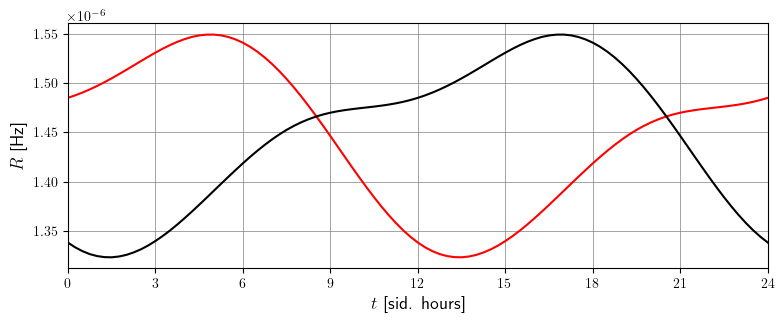

In [24]:
"""Plot R(t):"""
print(t_h)
fig = plt.figure(figsize=[2.0*unisize,unisize])
ax2 = fig.add_axes([0,0,1,0.7], xscale='linear', yscale='linear')
ax2.set_xlabel(r'$t$ [sid. hours]', fontsize=13, usetex=True)
ax2.set_ylabel(r'$R$ [Hz]', fontsize=13, usetex=True)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])

ax2.grid(color='gray', linestyle='-', linewidth=0.5)


ax2.plot(t_h, Ra_Hz, color='red')
ax2.plot(t_h, Rb_Hz, color='black')
# mX, n label:
"""
ax2.text(0.98, 0.96, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='right',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)
"""

# plt.savefig('out/modRate_mX{}_n{}_eg.png'.format(mX, n), 
#             format="png", dpi=600, bbox_inches='tight')

fig.show()

In [25]:
def poisson_upper_limit(n_obs, mu_b, cl=0.90):
    """
    Compute upper limit on signal mean mu_s at confidence level CL,
    given observed counts n_obs and expected background mu_b.
    
    Solves: P(X <= n_obs | mu_s + mu_b) = 1 - CL
    """
    alpha = 1.0 - cl  # 0.10 for 90% CL

    # If mu_s=0, check if we already exclude at this CL
    if poisson.cdf(n_obs, mu_b) <= alpha:
        return 0.0  # background alone already excludes

    def equation(mu_s):
        return poisson.cdf(n_obs, mu_s + mu_b) - alpha

    # Bracket the root: upper bound where CDF is well below alpha
    mu_s_upper = max(50, n_obs * 10)
    while poisson.cdf(n_obs, mu_s_upper + mu_b) > alpha:
        mu_s_upper *= 2

    mu_s_limit = brentq(equation, 0, mu_s_upper, xtol=1e-6)
    return mu_s_limit

In [93]:
# --- Your experiment parameters ---
exposure_time = 900   # seconds (set your actual exposure)
mu_b = 0 # expected background events

# Sensitivity limit: assume you observe n_obs = 0 (best case / projected)
# Or use n_obs = round(mu_b) for the "median expected" limit
n_obs = round(mu_b)

mu_s_limit = poisson_upper_limit(n_obs, mu_b, cl=0.90)

print(f"Expected background: {mu_b:.4f} events")
print(f"Observed events: {n_obs}")
print(f"90% CL upper limit on signal: {mu_s_limit:.4f} events")

Expected background: 0.0000 events
Observed events: 0
90% CL upper limit on signal: 2.3026 events


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96]
thetaN 0.7330382858376184
0
7.526305931482212e-39
7.669151487179765e-39
thetaN 0.7330382858376184
0
9.947741598601218e-41
1.0249486935579904e-40
thetaN 0.7330382858376184
0
2.330589559851344e-41
2.3719309637952796e-41
thetaN 0.7330382858376184
0
1.5546491120117768e-41
1.570249435786613e-41
thetaN 0.7330382858376184
0
2.0784868187882648e-41
2.0957232013296807e-41
thetaN 0.7330382858376184
0
2.797947452936048e-41
2.820269932512902e-41
thetaN 0.7330382858376184
0
4.3172879821643115e-41
4.350819644146521e-41
thetaN 0.7330382858376184
0
8.193729936554899e-41
8.256106760253674e-41


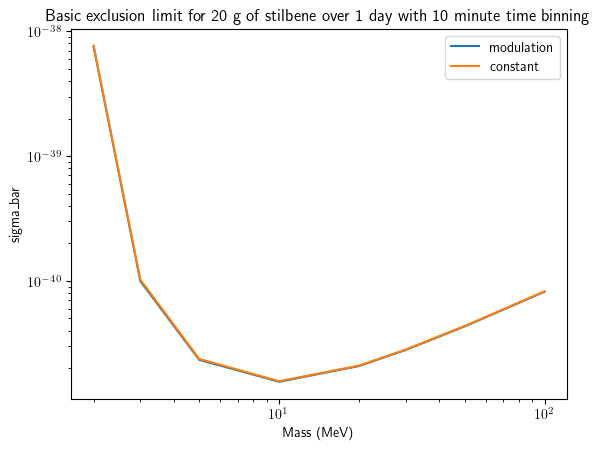

In [95]:
#Use the poisson upper limit found above to find the matching sigma for both a modulating signal and the average signal
#same result which makes sense (I think)

mXlist = [2, 3, 5, 10, 20, 30, 50, 100]
exclusion_sigma_mod = []
exclusion_sigma_avg = []
time_bins = np.arange(0, 97, 1)
print(time_bins)
for m in mXlist:
    dm_model = simpleRate('tot_n{}_mX{}'.format(0, m), sigma0_cm2 =1, mass_kg=1)
    avg_rate = 4*dm_model.isoR_Hz
    theta_north = 35*deg
    phi_north = 245*deg
    phase = 0*deg
    thetaN = 42*deg # close to the January average
    t_h, Ra_Hz = dm_model.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)
    rate = 4*Ra_Hz*900*365
    binned_sigma = 0
    binned_sigma_avg = 0
    print(binned_sigma)
    for t in time_bins:
        sigma = mu_s_limit/rate[t]
        avg_sigma = mu_s_limit/(avg_rate*900*365)
        #print(sigma)
        binned_sigma = binned_sigma+(1/sigma)
        binned_sigma_avg = binned_sigma_avg+(1/avg_sigma)
    print(1/binned_sigma)
    print(1/binned_sigma_avg)
    exclusion_sigma_mod.append(1/binned_sigma)
    exclusion_sigma_avg.append(1/binned_sigma_avg)
plt.loglog(mXlist, exclusion_sigma_mod, label = "modulation")
plt.loglog(mXlist, exclusion_sigma_avg, label = "constant")
plt.xlabel("Mass (MeV)")
plt.ylabel("sigma_bar")
plt.title("Basic exclusion limit for 20 g of stilbene over 1 day with 10 minute time binning")
plt.legend()
plt.show()



In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, minimize_scalar

def binned_poisson_limit(time_bins, signal_rate_func, R_b, sigma_ref,
                         n_obs=None, cl=0.90):
    
    dt = np.array([t[1] - t[0] for t in time_bins])
    t_centers = np.array([0.5*(t[0] + t[1]) for t in time_bins])
    
    # Always work with arrays internally
    if n_obs is None or np.isscalar(n_obs):
        n_obs_arr = np.zeros(len(time_bins), dtype=float)
    else:
        n_obs_arr = np.array(n_obs, dtype=float)

    # Precompute the rate shape — signal scales linearly with sigma
    #rate_shape = np.array([signal_rate_func(t, sigma_ref) for t in t_centers])
    t_h, Rb_Hz = dm_model.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)
    Rb_Hz *= sigma_ref
    print(Rb_Hz)
    def mu_total(sigma):
        mu_s = (sigma / sigma_ref) * Rb_Hz[:-1] * dt
        mu_b = R_b * dt
        return mu_s + mu_b  # always >= mu_b > 0

    def log_likelihood(sigma):
        mu = mu_total(sigma)
        return np.sum(-mu + n_obs_arr * np.log(mu))

    # Best-fit sigma: constrained to sigma >= 0 (physical)
    # With n_obs=0, log L = -sum(mu), maximized at sigma=0
    # So sigma_hat = 0, and log_L_hat = log_likelihood(0)
    result = minimize_scalar(
        lambda s: -log_likelihood(s),
        bounds=(0, sigma_ref * 1e4),
        method='bounded'
    )
    sigma_hat = max(result.x, 0.0)
    log_L_hat = log_likelihood(sigma_hat)
    
    print(f"sigma_hat = {sigma_hat:.3e} cm^2")
    print(f"log_L(sigma_hat) = {log_L_hat:.4f}")
    print(f"log_L(sigma_ref) = {log_likelihood(sigma_ref):.4f}")
    print(f"log_L(0)         = {log_likelihood(0):.4f}")

    # Cowan et al. (2011) q_mu for upper limits:
    # q_mu = -2 * (log L(mu) - log L(mu_hat))  if mu >= mu_hat
    #      = 0                                   if mu < mu_hat
    # Since sigma_hat ~ 0 and we only test sigma > 0, q_mu = -2*delta_log_L
    def q_mu(sigma):
        if sigma < sigma_hat:
            return 0.0  # don't penalize signal below best fit
        ll = log_likelihood(sigma)
        return -2.0 * (ll - log_L_hat)

    # CL_s+b: p-value of signal+background hypothesis
    # 90% CL upper limit: q_mu = chi2(1 dof) quantile for 1-sided = 2.706
    alpha = 1.0 - cl  # 0.10
    from scipy.stats import chi2
    q_threshold = chi2.ppf(1 - alpha, df=1)  # = 2.706 for 90% CL
    print(f"\nThreshold q_mu for {cl*100:.0f}% CL: {q_threshold:.4f}")

    # Scan to verify crossing exists and find bracket
    sigmas = np.logspace(
        np.log10(sigma_ref) - 6,
        np.log10(sigma_ref) + 2,
        300
    )
    q_vals = np.array([q_mu(s) for s in sigmas])
    """
    plt.figure(figsize=(8, 4))
    plt.semilogx(sigmas, q_vals, 'b-', lw=2, label='q(σ)')
    plt.axhline(q_threshold, color='r', ls='--', label=f'{cl*100:.0f}% CL threshold ({q_threshold:.3f})')
    plt.axvline(sigma_ref, color='gray', ls=':', label='sigma_ref')
    #plt.xlabel('σ (cm²)')
    #plt.ylabel('q(σ)')
    plt.title('Test statistic scan')
    plt.legend()
    plt.ylim(-0.5, min(q_vals.max() * 1.1, 50))
    #plt.tight_layout()
    plt.savefig('q_scan.png', dpi=120)
    plt.show()
    """
    print(f"\nq(sigma) range: [{q_vals.min():.4f}, {q_vals.max():.4f}]")

    # Find the crossing
    crossing = sigmas[q_vals > q_threshold]
    if len(crossing) == 0:
        raise ValueError(
            f"q never exceeds threshold {q_threshold:.3f}. "
            f"Max q = {q_vals.max():.4f}. "
            f"Try widening sigma range or check rate normalization."
        )
    
    # Bracket: last sigma where q < threshold, first where q > threshold
    idx = np.where(q_vals > q_threshold)[0][0]
    s_lo = sigmas[max(idx - 1, 0)]
    s_hi = sigmas[min(idx + 1, len(sigmas) - 1)]
    print(f"Crossing bracketed between {s_lo:.3e} and {s_hi:.3e} cm^2")

    sigma_limit = brentq(lambda s: q_mu(s) - q_threshold, s_lo, s_hi, xtol=1e-50)
    return sigma_limit


sigma_lim = binned_poisson_limit(time_bins, dm_model.dailyModMe, R_b, sigma_ref, n_obs=11.2)
print(f"\n90% CL upper limit: sigma < {sigma_lim:.3e} cm^2")

IndexError: invalid index to scalar variable.

In [29]:
def test_statistic(sigma):
    mu_0 = 900*R_b
    f = (sigma*Rb_Hz + R_b)/mu_0
    delta = 1 - n_obs/mu_0
    return np.sum(mu_0*(delta)**2 - mu_0/(f)*(delta-(f-1))**2 - np.log(f))

# Set up time bins (e.g. 1 day of data in 1-hour bins)
T_obs = 86400.0   # 1 day in seconds
n_bins = 96
edges = np.linspace(0, T_obs, n_bins + 1)
time_bins = [(edges[i], edges[i+1]) for i in range(n_bins)]
R_b = 3.2 #1.12  # events/sec background
theta_north = 35*deg
phi_north = 245*deg
phase = 180*deg
thetaN = 42*deg # close to the January average

dm_model = simpleRate('tot_n{}_mX{}'.format(0, 10), sigma0_cm2 =1, mass_kg=0.02)
t_h, Rb_Hz = dm_model.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)
print(Rb_Hz)
n_obs = round(R_b*900+100)
print(n_obs)
sigmas = np.logspace(-25, -35, 100)
for s in sigmas:
    print(s, test_statistic(s))


#print(f"90% CL upper limit: sigma < {sigma_lim:.3e} cm^2")

thetaN 0.7330382858376184
[2.16573999e+31 2.15881004e+31 2.15309388e+31 2.14856674e+31
 2.14538815e+31 2.14345525e+31 2.14274987e+31 2.14345716e+31
 2.14535496e+31 2.14859764e+31 2.15294482e+31 2.15848337e+31
 2.16524012e+31 2.17297525e+31 2.18166505e+31 2.19136043e+31
 2.20188940e+31 2.21311029e+31 2.22493083e+31 2.23728156e+31
 2.24999397e+31 2.26293062e+31 2.27595148e+31 2.28889367e+31
 2.30169747e+31 2.31414875e+31 2.32606448e+31 2.33738582e+31
 2.34800453e+31 2.35781917e+31 2.36675296e+31 2.37466627e+31
 2.38162638e+31 2.38760389e+31 2.39258934e+31 2.39663095e+31
 2.39966721e+31 2.40181741e+31 2.40318083e+31 2.40384603e+31
 2.40390463e+31 2.40346483e+31 2.40263933e+31 2.40154135e+31
 2.40028094e+31 2.39893910e+31 2.39763111e+31 2.39645937e+31
 2.39550520e+31 2.39484006e+31 2.39452379e+31 2.39460291e+31
 2.39510699e+31 2.39604221e+31 2.39743118e+31 2.39925957e+31
 2.40149560e+31 2.40410403e+31 2.40703411e+31 2.41021831e+31
 2.41357700e+31 2.41702191e+31 2.42044727e+31 2.42374540e+3

In [102]:
"THIS IS THE ACTUAL LIKELIHOOD CODE THAT WORKS"


# ── Experiment parameters ──────────────────────────────────────────────
num_days   = 365
T          = 86400      # observation time in seconds (1 hour)
R_b        = 0.017   # background rate (events/s) — your value
dt = 900
mu_b       = R_b*dt*num_days     # expected background events 
num_bins = 24*3600/dt

theta_north = 35*deg
phi_north = 245*deg
phase = 180*deg
thetaN = 42*deg # close to the January average
mXlist = [2, 3, 5, 10, 20, 30, 50, 100]
sigma_modulation_background = []
sigmas_shape_mod = []
sigmas_shape_avg = []
sigma_ref = 1E-50
print(mu_b)
n_obs = mu_b
N = n_obs*num_bins 

# or use n_obs = 0 for the most optimistic projected limit
# Signal scales linearly with cross section


def mu_signal(sigma):
    rate = sigma * Rb_Hz * dt 
    return np.sum(rate)
    
def log_likelihood(sigma, n_obs_bins, rate):
    mu_s = sigma*Rb_Hz * dt
    mu_total = mu_s + mu_b
    return np.sum(-mu_total + n_obs_bins * np.log(mu_total))

def gauss_log_likelihood(sigma, n_obs_bins, rate):
    mu_s = sigma*Rb_Hz * dt*num_days
    mu_total = mu_s + mu_b
    return np.sum(np.log(2*np.pi*mu_total)+(n_obs_bins-mu_total)**2/mu_total)

def test_statistic(sigma, rate):
    mu_s = sigma*rate*dt*num_days
    mu_total = mu_s + mu_b
    ts = N/num_bins*np.sum(n_obs/mu_total -1)**2
    return ts
    
def limit_binned(n_obs_bins, rate):
    # sigma_hat = 0 when n_obs=0 or underdispersed
    log_L_hat = test_statistic(0, rate)
    
    def q_mu(sigma):
        q = max((test_statistic(sigma, rate) - log_L_hat), 0)
        return q    
    sigma_hi = sigma_ref
    while q_mu(sigma_hi) < 2.706:
        sigma_hi *= 1.5
    return brentq(lambda s: q_mu(s) - 2.706, 0, sigma_hi, xtol=1e-60)

n_bins = int(num_bins+1)
n_obs_bins  = np.full(n_bins, round(mu_b)) 

for m in mXlist:
    print(m)
    dm_model = simpleRate('tot_n{}_mX{}'.format(0, m), sigma0_cm2 =1, mass_kg=1)
    Rb_Hz_avg = 4*dm_model.isoR_Hz
    t_h, Rb_Hz = dm_model.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)
    lim2 = limit_binned(n_obs_bins, Rb_Hz)
    lim_avg = limit_binned(n_obs_bins, Rb_Hz_avg)
    sigmas_shape_mod.append(lim2)
    sigmas_shape_avg.append(lim_avg)
    print(f"Shape-aware limit:  {lim2:.3e} cm^2")

print(sigmas_shape_mod)
print(sigmas_shape_avg)




5584.5
2
thetaN 0.7330382858376184
Shape-aware limit:  1.615e-36 cm^2
3
thetaN 0.7330382858376184
Shape-aware limit:  2.132e-38 cm^2
5
thetaN 0.7330382858376184
Shape-aware limit:  4.988e-39 cm^2
10
thetaN 0.7330382858376184
Shape-aware limit:  3.324e-39 cm^2
20
thetaN 0.7330382858376184
Shape-aware limit:  4.443e-39 cm^2
30
thetaN 0.7330382858376184
Shape-aware limit:  5.981e-39 cm^2
50
thetaN 0.7330382858376184
Shape-aware limit:  9.228e-39 cm^2
100
thetaN 0.7330382858376184
Shape-aware limit:  1.751e-38 cm^2
[1.6153669114851343e-36, 2.1318520883874107e-38, 4.988024119594227e-39, 3.324102070177583e-39, 4.4429891818689013e-39, 5.980581123432016e-39, 9.227784948496583e-39, 1.7512778875809366e-38]
[4.0609360979453157e-35, 5.427264222345069e-37, 1.2559746783998672e-37, 8.314717250303081e-38, 1.1097183324397826e-37, 1.4933772000770689e-37, 2.3038272979872343e-37, 4.371738128690139e-37]


python3(99549) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(99555) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(99559) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


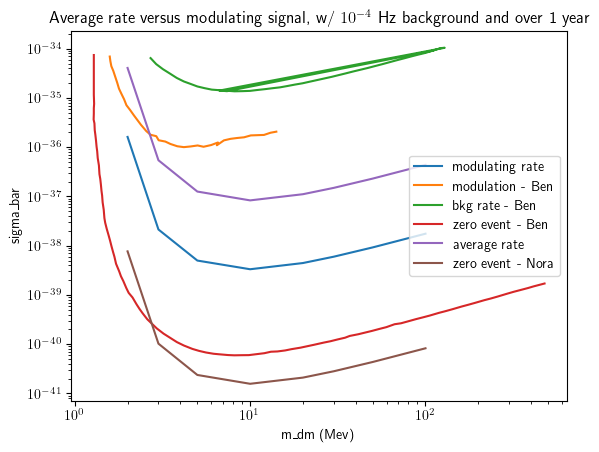

In [103]:
import pandas as pd
modulation = pd.read_csv("modulation.csv")
bkg_ben = pd.read_csv("Background_rate.csv")
zero_event_ben = pd.read_csv("zero_events.csv")
plt.loglog(mXlist, sigmas_shape_mod, label = "modulating rate")
plt.loglog(modulation.iloc[:,0], modulation.iloc[:,1], label = "modulation - Ben")
plt.loglog(bkg_ben.iloc[:,0], bkg_ben.iloc[:,1], label = "bkg rate - Ben")
plt.loglog(zero_event_ben.iloc[:,0], zero_event_ben.iloc[:,1], label = "zero event - Ben")
plt.loglog(mXlist,  sigmas_shape_avg, label = "average rate")
plt.loglog(mXlist, exclusion_sigma_avg, label = "zero event - Nora")
plt.ylabel("sigma_bar")
plt.xlabel("m_dm (Mev)")
plt.title(r"Average rate versus modulating signal, w/ $10^{-4}$ Hz background and over 1 year")
plt.legend()
plt.show()

In [50]:
#Try to do monte-carlo version of this, using average rate of events
#for null hypothesis than we have events with a mean value of 1E-4 
def log_likelihood(mu, n, b, s):
    lam = b + mu * s
    return n * np.log(lam) - lam  # drop constant n! term

def q_tilde(mu, n, b, s):
    mu_hat = max(0, (n - b) / s)
    ll_num = log_likelihood(mu, n, b, s)
    ll_den = log_likelihood(mu_hat, n, b, s)
    q = -2 * (ll_num - ll_den)
    return 0.0 if mu_hat > mu else q


def compute_cls(mu, n_obs, b, s, n_toys=50000):
    q_obs = q_tilde(mu, n_obs, b, s)
    
    # generate toys at this specific mu
    null_ns   = np.random.poisson(b, n_toys)
    signal_ns = np.random.poisson(b + mu * s, n_toys)  # ← mu varies here
    
    q_b  = np.array([q_tilde(mu, n, b, s) for n in null_ns])
    q_sb = np.array([q_tilde(mu, n, b, s) for n in signal_ns])
    
    cl_b  = np.mean(q_b  >= q_obs)
    cl_sb = np.mean(q_sb >= q_obs)
    
    if cl_b == 0:
        return 1.0
    return cl_sb / cl_b

mXlist = [2, 3, 5, 10, 20, 30, 50, 100]
b = 1E-4*86400*365
print(b)
n_obs = round(1E-4*86400*365)

lo, hi = 0, 500
avg_cls_limits = []
for m in mXlist:
    dm_model = simpleRate('tot_n{}_mX{}'.format(0, m), sigma0_cm2 =1E-38, mass_kg=1)
    Rb_Hz_avg = dm_model.isoR_Hz
    print(m, Rb_Hz_avg)
    s = (Rb_Hz_avg)*86400*365
    lo, hi = 0, 500
    for _ in range(30):
        mid = (lo + hi)/2
        cls = compute_cls(mid, n_obs, b, s, n_toys= 10000)
        print(cls)
        if cls > 0.05:
            lo = mid
        else:
            hi = mid
    limit = (lo + hi)/2
    avg_cls_limits.append(limit*1E-38)
print(avg_cls_limits)


3153.6000000000004
2 2.3555985188551027e-08
0.000984251968503937
0.10752264671130367
0.01321499013806706
0.040674603174603176
0.06546677215189872
0.05476996614220275
0.04504504504504504
0.05130198212203654
0.0488774090999404
0.05072181037846274
0.0476657512750098
0.048679542767047695
0.047749510763209393
0.04678136477865842
0.052902714483851795
0.047553546865788957
0.05168629016164438
0.04637964774951076
0.04928613338548798
0.04841897233201581
0.05217391304347826
0.05640305098354075
0.05057064147973239
0.049606299212598425
0.05025420414548299
0.052942334186183826
0.05219454329774614
0.0555667001003009
0.050098619329388555
0.04952076677316294
3 1.7625703606064448e-06
0.0
0.0
0.0
0.0
0.0
0.0
0.00019204916458613405
0.05487564153178049
0.003340538416191786
0.017653981953707334
0.03301611963488056
0.0345099585880497
0.04914054600606673
0.05134762935274445
0.0525483998419597
0.05323938148365629
0.049790041991601676
0.04866905045689313
0.04855514055435423
0.05298940211957608
0.051312649164677

KeyboardInterrupt: 

In [ ]:
data = np.load("avg_cls_limits.npy")
print(data)

In [ ]:
plt.loglog(mXlist, sigmas_shape_mod, label = "Asymptotic limit - modulating rate")
plt.loglog(mXlist, avg_cls_limits, label = "Toys - average rate")
plt.loglog(mXlist,  sigmas_shape_avg, label = "Asymptotic limit - average rate")
plt.ylabel("sigma_bar")
plt.xlabel("m_dm (Mev)")
plt.title(r"Average rate versus modulating signal, w/ $10^{-4}$ Hz background and over 1 year")
plt.legend()
plt.show()

In [ ]:
def log_likelihood_binned(mu, ns, bs, ss):
    lams = bs + mu * ss          # shape (n_bins,)
    valid = lams > 0
    ll = np.where(valid, ns * np.log(np.where(valid, lams, 1)) - lams, -np.inf)
    return np.sum(ll)
    
def mu_hat_approx(ns, bs, ss):
    # asymptotic closed-form estimate
    # safe where bs > 0
    weights = np.where(bs > 0, ss**2 / bs, 0)
    numerator = np.where(bs > 0, (ns - bs) * ss / bs, 0)
    denom = np.sum(weights)
    if denom == 0:
        return 0.0
    return max(0.0, np.sum(numerator) / denom)

def mu_hat_binned(ns, bs, ss):
    # use asymptotic estimate as starting point for the optimizer
    mu0 = mu_hat_approx(ns, bs, ss)
    
    result = minimize_scalar(
        lambda mu: -log_likelihood_binned(mu, ns, bs, ss),
        bounds=(0, max(mu0 * 10, 1e3)),   # tighter upper bound
        method='bounded',
        options={'xatol': 1e-4}           # looser tolerance is fine here
    )
    return result.x

def q_tilde_binned(mu, ns, bs, ss):
    muhat = mu_hat_binned(ns, bs, ss)
    ll_num = log_likelihood_binned(mu, ns, bs, ss)
    ll_den = log_likelihood_binned(muhat, ns, bs, ss)
    q = -2 * (ll_num - ll_den)
    return 0.0 if muhat > mu else max(0.0, q)

def generate_toys(mu, bs, ss, n_toys):
    # returns array of shape (n_toys, n_bins)
    lams = bs + mu * ss   # bs, ss are numpy arrays over bins
    return np.random.poisson(lams, size=(n_toys, len(bs)))

def compute_cls_binned(mu, n_obs, bs, ss, n_toys=5):
    q_obs = q_tilde_binned(mu, n_obs, bs, ss)
    null_toys   = generate_toys(0,  bs, ss, n_toys)   # shape (n_toys, n_bins)
    signal_toys = generate_toys(mu, bs, ss, n_toys)  
    q_b  = np.array([q_tilde_binned(mu, toy, bs, ss) for toy in null_toys])
    q_sb = np.array([q_tilde_binned(mu, toy, bs, ss) for toy in signal_toys])
    
    cl_b  = np.mean(q_b  >= q_obs)
    cl_sb = np.mean(q_sb >= q_obs)
    return cl_sb / cl_b if cl_b > 0 else 1.0
mod_cls_limits = []

for m in mXlist:
    dm_model = simpleRate('tot_n{}_mX{}'.format(0, m), sigma0_cm2 =1E-38, mass_kg=1)
    t_h, Rb_Hz = dm_model.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)
    b = np.full(len(Rb_Hz), 1E-4*900*365)
    n_obs = np.full(len(Rb_Hz), round(1E-4*900*365))
    #Rb_Hz_avg = dm_model.isoR_Hz
    s = Rb_Hz*900*365
    lo, hi = 0, 500
    for _ in range(30):
        mid = (lo + hi)/2
        print(mid)
        cls = compute_cls_binned(mid, n_obs, b, s, n_toys= 1000)
        print(cls)
        if cls > 0.05:
           lo = mid
        else:
            hi = mid    
    limit = (lo + hi)/2
    mod_cls_limits.append(limit*1E-38)
print(limit)


In [ ]:
contours = [1, 10, 100, 1000, 10000]
n_dms = [[],[], [], [], []]
for i,c in enumerate(contours): 
    for m in mXlist:
        lo, hi = 0, 10000
        for _ in range(30):
            mid = (lo + hi)/2
            dm_model = simpleRate('tot_n{}_mX{}'.format(0, m), sigma0_cm2 = 1E-38*mid, mass_kg=1)
            Rb_Hz = dm_model.isoR_Hz
            if Rb_Hz*86400*365 > c:
                hi = mid
            else:
                lo = mid   
        n_dms[i].append(mid*1E-38)
print(n_dms)

In [ ]:
dm_model = simpleRate('tot_n{}_mX{}'.format(0, 10), sigma0_cm2 = 1.3461429625749586e-40, mass_kg=1)
Rb_Hz = dm_model.isoR_Hz
print(Rb_Hz*86400*365)

In [ ]:
plt.loglog(mXlist,  sigmas_shape_avg, label = "Asymptotic limit - average rate")
plt.loglog(mXlist, sigmas_shape_mod, label = "Asymptotic limit - modulating rate")
np.save("avg_cls_limits.npy", avg_cls_limits)
np.save("mod_cls_limits.npy", mod_cls_limits)
np.save("sigmas_shape_avg.npy", sigmas_shape_avg)
np.save("sigmas_shape_mod.npy", sigmas_shape_mod)
plt.loglog(mXlist, avg_cls_limits, label = "Toys - average rate")
plt.loglog(mXlist,  mod_cls_limits, label = "Toys - modulating rate")
plt.loglog(mXlist,  n_dms[0], '--', color = "0", label = "N_dm = 1")
plt.loglog(mXlist,  n_dms[1], '--', color = "0.2",label = "N_dm = 10")
plt.loglog(mXlist,  n_dms[2], '--', color = "0.4",label = "N_dm = 100")
plt.loglog(mXlist,  n_dms[3], '--', color = "0.6",label = "N_dm = 1000")
plt.loglog(mXlist,  n_dms[4], '--', color = "0.8",label = "N_dm = 10000")
plt.ylabel("sigma_bar")
plt.xlabel("m_dm (Mev)")
plt.title(r"Average rate versus modulating signal, w/ $10^{-4}$ Hz background and over 1 year")
plt.legend()
plt.show()

In [ ]:
#avg_cls_limits = np.load("avg_cls_limits.npy")
#mod_cls_limits = np.load("mod_cls_limits.npy")
avg_toy_ndm = []
mod_toy_ndm = []
avg_ts_ndm  = []
mod_ts_ndm  = []
for i, m in enumerate(mXlist):
    dm_model_mts = simpleRate('tot_n{}_mX{}'.format(0, m), sigma0_cm2 = sigmas_shape_mod[i], mass_kg=1)
    t_h, Rb_Hz_mts = dm_model_mts.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)
    mod_ts_ndm.append(sum(Rb_Hz_mts)*900*365)
    
    dm_model_ats = simpleRate('tot_n{}_mX{}'.format(0, m), sigma0_cm2 = sigmas_shape_avg[i], mass_kg=1)
    Rb_Hz_ats = dm_model_ats.isoR_Hz
    avg_ts_ndm.append(Rb_Hz_ats*86400*365)

    dm_model_mtoy = simpleRate('tot_n{}_mX{}'.format(0, m), sigma0_cm2 = mod_cls_limits[i], mass_kg=1)
    t_h, Rb_Hz_mtoy = dm_model_mtoy.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)
    mod_toy_ndm.append(sum(Rb_Hz_mtoy)*900*365)

    dm_model_atoy = simpleRate('tot_n{}_mX{}'.format(0, m), sigma0_cm2 = avg_cls_limits[i], mass_kg=1)
    Rb_Hz_atoy = dm_model_atoy.isoR_Hz
    avg_toy_ndm.append(Rb_Hz_atoy*86400*365)

print(avg_toy_ndm[1])
print(mod_toy_ndm[1])
print(avg_ts_ndm[1])
print(mod_ts_ndm[1])
plt.loglog(mXlist,  avg_ts_ndm, label = "Asymptotic limit - average rate")
plt.loglog(mXlist, mod_ts_ndm, label = "Asymptotic limit - modulating rate")
plt.loglog(mXlist, avg_toy_ndm, label = "Toys - average rate")
plt.loglog(mXlist,  mod_toy_ndm, label = "Toys - modulating rate")
plt.ylabel("Total Number of dark matter events")
plt.xlabel("m_dm (Mev)")
plt.title(r"Average rate versus modulating signal, w/ $10^{-4}$ Hz background and over 1 year")
plt.legend()
plt.show()

In [ ]:
1E-4*86400*365


In [ ]:
from scipy.optimize import minimize
def b_shifted(theta, b0, sigma_b):
    return b0 * (1 + sigma_b * theta)

def log_likelihood_nuisance(mu, theta, n, b0, s, sigma_b):
    b = b_shifted(theta, b0, sigma_b)
    lam = b + mu * s
    if lam <= 0:
        return -np.inf
    return n * np.log(lam) - lam# - 0.5 * theta**2   # gaussian penalty

def profile_theta(mu, n, b0, s, sigma_b):
    # find theta_hat_hat at fixed mu
    result = minimize_scalar(
        lambda theta: -log_likelihood_nuisance(mu, theta, n, b0, s, sigma_b),
        bounds=(-1, 1),
        method='bounded'
    )
    return result.x
    
def global_mle_nuisance(n, b0, s, sigma_b):
    # find mu_hat, theta_hat jointly
    result = minimize(
        lambda x: -log_likelihood_nuisance(x[0], x[1], n, b0, s, sigma_b),
        x0=[0.0, 0.0],
        bounds=[(0, None), (-5, 5)]
    )
    return result.x   # (mu_hat, theta_hat)


def q_tilde_nuisance(mu, n, b0, s, sigma_b):
    mu_hat, theta_hat = global_mle_nuisance(n, b0, s, sigma_b)
    theta_cond        = profile_theta(mu, n, b0, s, sigma_b)
    #print(mu_hat, theta_hat, theta_cond)
    ll_num = log_likelihood_nuisance(mu,     theta_cond, n, b0, s, sigma_b)
    ll_den = log_likelihood_nuisance(mu_hat, theta_hat,  n, b0, s, sigma_b)
    #print("ll", ll_num, ll_den)
    q = -2 * (ll_num - ll_den)
    return 0.0 if mu_hat > mu else q

def compute_cls_nuisance(mu, n_obs, b0, s, sigma_b, n_toys=20000):
    q_obs = q_tilde_nuisance(mu, n_obs, b0, s, sigma_b)
    #print("q obs: ", q_obs)
    # generate toys at nominal theta=0
    null_ns   = np.random.poisson(b0,          n_toys)
    signal_ns = np.random.poisson(b0 + mu * s, n_toys)

    q_b  = np.array([q_tilde_nuisance(mu, n, b0, s, sigma_b) for n in null_ns])
    #print("q_b: ", q_b)
    q_sb = np.array([q_tilde_nuisance(mu, n, b0, s, sigma_b) for n in signal_ns])
    #print("q_sb: ", q_sb)
    
    cl_b  = np.mean(q_b  >= q_obs)
    cl_sb = np.mean(q_sb >= q_obs)
    return cl_sb / cl_b if cl_b > 0 else 1.0

avg_bkg_cls_limit = []

#cls = compute_cls_nuisance(8.5, 3150, b, s, 1, n_toys = 100)

for m in mXlist:
    dm_model = simpleRate('tot_n{}_mX{}'.format(0, m), sigma0_cm2 =1E-38, mass_kg=1)
    #t_h, Rb_Hz = dm_model.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)
    b = 1E-4*86400*365
    n_obs = round(1E-4*86400*365)
    Rb_Hz_avg = dm_model.isoR_Hz
    s = Rb_Hz_avg*86400*365
    lo, hi = 0, 5000
    for _ in range(30):
        mid = (lo + hi)/2
        print(mid)
        cls = compute_cls_nuisance(mid, n_obs, b, s, 1, n_toys= 10000)
        print(cls)
        if cls > 0.05:
            lo = mid
        else:
            hi = mid    
    limit = (lo + hi)/2
    print(limit*1E-38)
    avg_bkg_cls_limit.append(limit*1E-38)
print(avg_bkg_cls_limit)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
mXlist = [2, 3, 5, 10, 20, 30, 50, 100]

avg_bkg_cls_limits = [4.2457530950196084e-35, 5.674264160916209e-37, 1.3131352607160807e-37, 8.693130221217871e-38, 1.1602228041738272e-37, 1.5613420400768518e-37, 2.4086765479296444e-37, 4.57069999538362e-37]
avg_cls_limits = np.load("avg_cls_limits.npy")
mod_cls_limits = np.load("mod_cls_limits.npy")
sigmas_shape_avg = np.load("sigmas_shape_avg.npy")
sigmas_shape_mod = np.load("sigmas_shape_mod.npy")
plt.loglog(mXlist,  sigmas_shape_avg, label = "Asymptotic limit - average rate")
plt.loglog(mXlist, sigmas_shape_mod, label = "Asymptotic limit - modulating rate")
plt.loglog(mXlist, avg_bkg_cls_limits, label = "Toys - background varying average")
plt.loglog(mXlist, avg_cls_limits, label = "Toys - average rate")
plt.loglog(mXlist,  mod_cls_limits, label = "Toys - modulating rate")
#plt.loglog(mXlist,  n_dms[0], '--', color = "0", label = "N_dm = 1")
#plt.loglog(mXlist,  n_dms[1], '--', color = "0.2",label = "N_dm = 10")
#plt.loglog(mXlist,  n_dms[2], '--', color = "0.4",label = "N_dm = 100")
#plt.loglog(mXlist,  n_dms[3], '--', color = "0.6",label = "N_dm = 1000")
#plt.loglog(mXlist,  n_dms[4], '--', color = "0.8",label = "N_dm = 10000")
plt.ylabel("sigma_bar")
plt.xlabel("m_dm (Mev)")
plt.title(r"Average rate versus modulating signal, w/ $10^{-4}$ Hz background and over 1 year")
plt.legend()
plt.show()

In [ ]:
43.46*1E-38
dm_model_ats = simpleRate('tot_n{}_mX{}'.format(0, 10), sigma0_cm2 = 8.693*1E-38, mass_kg=1)
Rb_Hz_ats = dm_model_ats.isoR_Hz
print(Rb_Hz_ats*86400*365)

In [ ]:
def log_likelihood_nuisance_binned(mu, theta, ns, b0, ss, sigma_b):
    mu = float(mu)
    theta = float(theta)
    bs = b0 + (1+sigma_b*theta)
    lams = bs + mu * ss
    valid = lams > 0
    ll = np.where(valid, ns* np.log(np.where(valid, lams, 1)) - lams, -np.inf)
    return np.sum(ll)
    
def mu_hat_approx(ns, bs, ss):
    # asymptotic closed-form estimate
    # safe where bs > 0
    weights = np.where(bs > 0, ss**2 / bs, 0)
    numerator = np.where(bs > 0, (ns - bs) * ss / bs, 0)
    denom = np.sum(weights)
    if denom == 0:
        return 0.0
    return max(0.0, np.sum(numerator) / denom)

def global_mle_nuisance_binned(ns, b0s, ss, sigma_b):
    # find mu_hat, theta_hat jointly
    # force everything to plain numpy arrays / scalars
    ns  = np.asarray(ns,  dtype=float)
    b0s = np.asarray(b0s, dtype=float)
    ss  = np.asarray(ss,  dtype=float)
    sigma_b = float(sigma_b)

    # warm start from asymptotic approximation
    mu0 = float(mu_hat_approx(ns, b0s, ss))
    result = minimize(
        lambda x: -log_likelihood_nuisance_binned(x[0], x[1], ns, b0s, ss, sigma_b),
        x0=[mu0, 0.0],
        bounds=[(0, None), (-5, 5)]
    )
    return result.x   # (mu_hat, theta_hat)
    
def global_mle_nuisance(n, b0, s, sigma_b):
    # find mu_hat, theta_hat jointly
    result = minimize(
        lambda x: -log_likelihood_nuisance(x[0], x[1], n, b0, s, sigma_b),
        x0=[0.0, 0.0],
        bounds=[(0, None), (-5, 5)]
    )
    return result.x   # (mu_hat, theta_hat)
def profile_theta_binned(mu, n, b0, s, sigma_b):
    # find theta_hat_hat at fixed mu
    result = minimize_scalar(
        lambda theta: -log_likelihood_nuisance_binned(mu, theta, n, b0, s, sigma_b),
        bounds=(-1, 1),
        method='bounded'
    )
    return result.x
    
def mu_hat_binned(ns, bs, ss):
    # use asymptotic estimate as starting point for the optimizer
    mu0 = mu_hat_approx(ns, bs, ss)
    
    result = minimize_scalar(
        lambda mu: -log_likelihood_nuisance_binned(mu, ns, bs, ss),
        bounds=(0, max(mu0 * 10, 1e3)),   # tighter upper bound
        method='bounded',
        options={'xatol': 1e-4}           # looser tolerance is fine here
    )
    return result.x
    
def q_tilde_nuisance_binned(mu, n, b0, s, sigma_b):
    mu_hat, theta_hat = global_mle_nuisance_binned(n, b0, s, sigma_b)
    theta_cond        = profile_theta_binned(mu, n, b0, s, sigma_b)
    #print(mu_hat, theta_hat, theta_cond)
    ll_num = log_likelihood_nuisance_binned(mu,     theta_cond, n, b0, s, sigma_b)
    ll_den = log_likelihood_nuisance_binned(mu_hat, theta_hat,  n, b0, s, sigma_b)
    #print("ll", ll_num, ll_den)
    q = -2 * (ll_num - ll_den)
    return 0.0 if mu_hat > mu else q

def generate_toys(mu, bs, ss, n_toys):
    # returns array of shape (n_toys, n_bins)
    lams = bs + mu * ss   # bs, ss are numpy arrays over bins
    return np.random.poisson(lams, size=(n_toys, len(bs)))

def compute_cls_nuisance_binned(mu, n_obs, bs, ss, sigma_b, n_toys=5):
    q_obs = q_tilde_nuisance_binned(mu, n_obs, bs, ss, sigma_b)
    null_toys   = generate_toys(0,  bs, ss, n_toys)   # shape (n_toys, n_bins)
    signal_toys = generate_toys(mu, bs, ss, n_toys)  
    q_b  = np.array([q_tilde_nuisance_binned(mu, toy, bs, ss, sigma_b) for toy in null_toys])
    q_sb = np.array([q_tilde_nuisance_binned(mu, toy, bs, ss, sigma_b) for toy in signal_toys])
    
    cl_b  = np.mean(q_b  >= q_obs)
    cl_sb = np.mean(q_sb >= q_obs)
    return cl_sb / cl_b if cl_b > 0 else 1.0
mod_cls_bkg_limits = []

for m in mXlist:
    dm_model = simpleRate('tot_n{}_mX{}'.format(0, m), sigma0_cm2 =1E-38, mass_kg=1)
    t_h, Rb_Hz = dm_model.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)
    b = np.full(len(Rb_Hz), 1E-4*900*365)
    n_obs = np.full(len(Rb_Hz), round(1E-4*900*365))
    #Rb_Hz_avg = dm_model.isoR_Hz
    s = Rb_Hz*900*365
    lo, hi = 0, 5000
    for _ in range(30):
        mid = (lo + hi)/2
        print(mid)
        cls = compute_cls_nuisance_binned(mid, n_obs, b, s, 1, n_toys= 1000)
        print(cls)
        if cls > 0.05:
           lo = mid
        else:
            hi = mid    
    limit = (lo + hi)/2
    mod_cls_bkg_limits.append(limit*1E-38)
print(mod_cls_bkg_limits)
np.save("mod_cls_bkg_limits.npy", mod_cls_bkg_limits)


In [ ]:
avg_bkg_cls_limits = [4.2457530950196084e-35, 5.674264160916209e-37, 1.3131352607160807e-37, 8.693130221217871e-38, 1.1602228041738272e-37, 1.5613420400768518e-37, 2.4086765479296444e-37, 4.57069999538362e-37]
avg_cls_limits = np.load("avg_cls_limits.npy")
mod_cls_limits = np.load("mod_cls_limits.npy")
sigmas_shape_avg = np.load("sigmas_shape_avg.npy")
sigmas_shape_mod = np.load("sigmas_shape_mod.npy")
plt.loglog(mXlist,  sigmas_shape_avg, label = "Asymptotic limit - average rate")
plt.loglog(mXlist, sigmas_shape_mod, label = "Asymptotic limit - modulating rate")
plt.loglog(mXlist,  mod_cls_bkg_limits, label = "Toys - background varying modulation")
plt.loglog(mXlist, avg_bkg_cls_limits, label = "Toys - background varying average")
plt.loglog(mXlist, avg_cls_limits, label = "Toys - average rate")
plt.loglog(mXlist,  mod_cls_limits, label = "Toys - modulating rate")
plt.loglog(mXlist,  n_dms[0], '--', color = "0", label = "N_dm = 1")
plt.loglog(mXlist,  n_dms[1], '--', color = "0.2",label = "N_dm = 10")
plt.loglog(mXlist,  n_dms[2], '--', color = "0.4",label = "N_dm = 100")
plt.loglog(mXlist,  n_dms[3], '--', color = "0.6",label = "N_dm = 1000")
plt.loglog(mXlist,  n_dms[4], '--', color = "0.8",label = "N_dm = 10000")
plt.ylabel("sigma_bar")
plt.xlabel("m_dm (Mev)")
plt.title(r"Average rate versus modulating signal, w/ $10^{-4}$ Hz background and over 1 year")
plt.legend()
plt.show()